In [1]:
import sys
sys.path.insert(0, '/Users/nikitachizhikov/workspace/review_house_pricing')


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from omegaconf import OmegaConf
from pathlib import Path

%matplotlib inline

from config.config import py_config

%load_ext autoreload
%autoreload 2

In [2]:
if isinstance(py_config, dict):
    cfg_dict = py_config.copy()
else:
    cfg_dict = OmegaConf.to_container(py_config, resolve=False)

print('Notebook version: brainstorm_dense_v1')

Notebook version: brainstorm_dense_v1


In [3]:
raw_train_path = Path(cfg_dict['path']['raw']['train'])
raw_test_path = Path(cfg_dict['path']['raw']['test'])
target = cfg_dict['data']['target']

raw_train_data = pd.read_csv(raw_train_path)
raw_test_data = pd.read_csv(raw_test_path)
print(raw_train_data.columns)
print(raw_train_data.shape)
raw_train_data.describe()

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
print('train shape:', raw_train_data.shape)
print('test shape: ', raw_test_data.shape)
print()
print('Integer columns:', raw_train_data.select_dtypes(include='number').shape[1])
print('Categorial columns:', raw_train_data.select_dtypes(include='object').shape[1])

train shape: (1460, 81)
test shape:  (1459, 80)

Integer columns: 38
Categorial columns: 43


In [5]:
import numpy as np
print(raw_train_data['SalePrice'].describe())
print(raw_train_data['SalePrice'].skew())
print(np.log1p(raw_train_data['SalePrice']).skew())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
1.8828757597682129
0.12134661989685329


              count   pct
PoolQC         1453  99.5
MiscFeature    1406  96.3
Alley          1369  93.8
Fence          1179  80.8
MasVnrType      872  59.7
FireplaceQu     690  47.3
LotFrontage     259  17.7
GarageType       81   5.5
GarageYrBlt      81   5.5
GarageFinish     81   5.5
GarageQual       81   5.5
GarageCond       81   5.5
BsmtFinType2     38   2.6
BsmtExposure     38   2.6
BsmtFinType1     37   2.5
BsmtCond         37   2.5
BsmtQual         37   2.5
MasVnrArea        8   0.5
Electrical        1   0.1


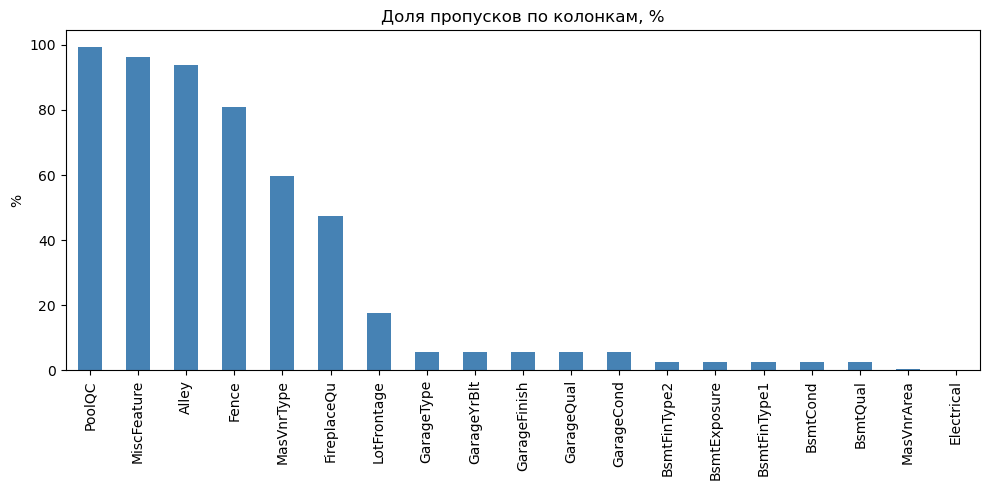

In [6]:
missing = raw_train_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(raw_train_data) * 100).round(1)
# print(missing_pct)

missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
missing_pct.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Доля пропусков по колонкам, %')
ax.set_ylabel('%')
plt.tight_layout()
plt.show()

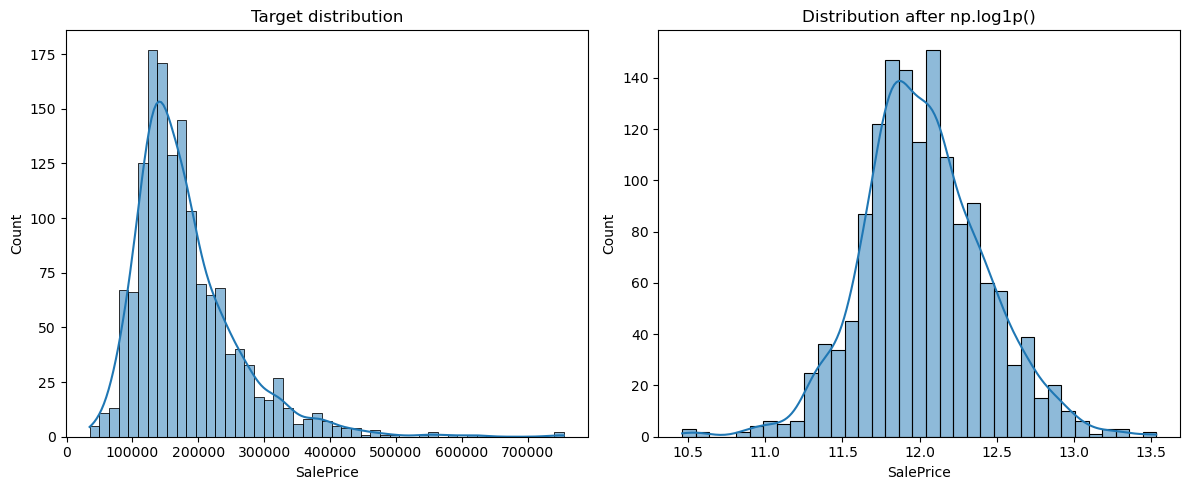

In [7]:
from src.eda.plots import plot_target_distribution, plot_missing_map, plot_top_corralations
plot_target_distribution(raw_train_data, py_config.data.target)



------- Missing --------
              count   pct
PoolQC         1453  99.5
MiscFeature    1406  96.3
Alley          1369  93.8
Fence          1179  80.8
MasVnrType      872  59.7
FireplaceQu     690  47.3
LotFrontage     259  17.7
GarageType       81   5.5
GarageYrBlt      81   5.5
GarageFinish     81   5.5
GarageQual       81   5.5
GarageCond       81   5.5
BsmtFinType2     38   2.6
BsmtExposure     38   2.6
BsmtFinType1     37   2.5
BsmtCond         37   2.5
BsmtQual         37   2.5
MasVnrArea        8   0.5
Electrical        1   0.1


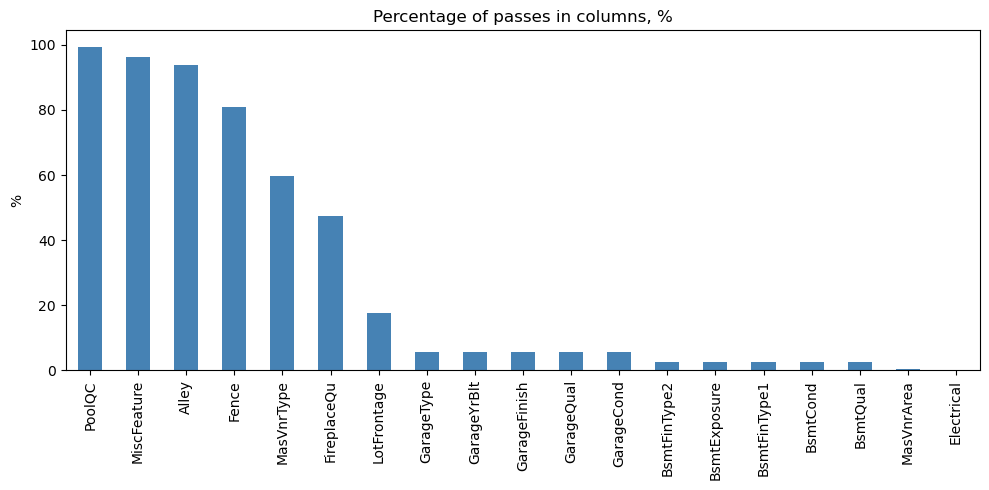

In [8]:
plot_missing_map(raw_train_data)

                  corr
SalePrice     1.000000
OverallQual   0.790982
GrLivArea     0.708624
GarageCars    0.640409
GarageArea    0.623431
TotalBsmtSF   0.613581
1stFlrSF      0.605852
FullBath      0.560664
TotRmsAbvGrd  0.533723
YearBuilt     0.522897
YearRemodAdd  0.507101
GarageYrBlt   0.486362
MasVnrArea    0.477493
Fireplaces    0.466929
BsmtFinSF1    0.386420
LotFrontage   0.351799


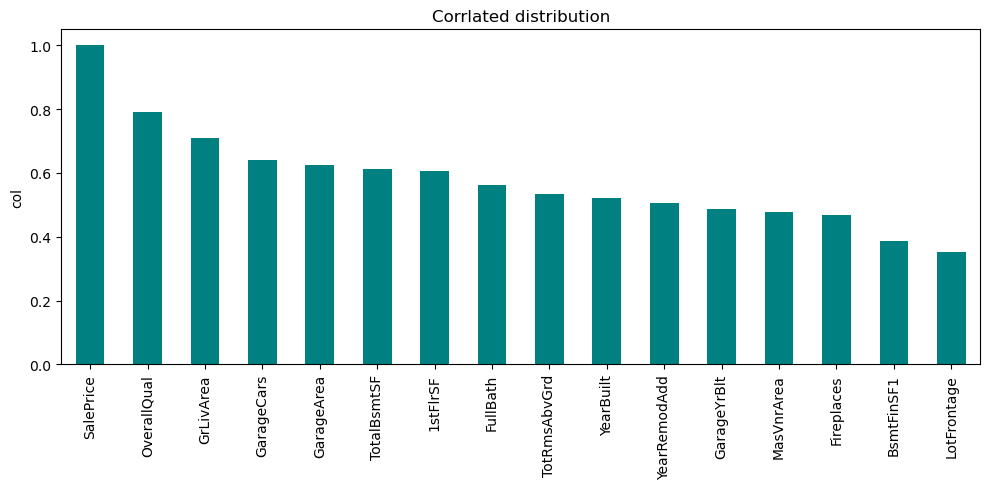

In [9]:
plot_top_corralations(raw_train_data, target, top=15)

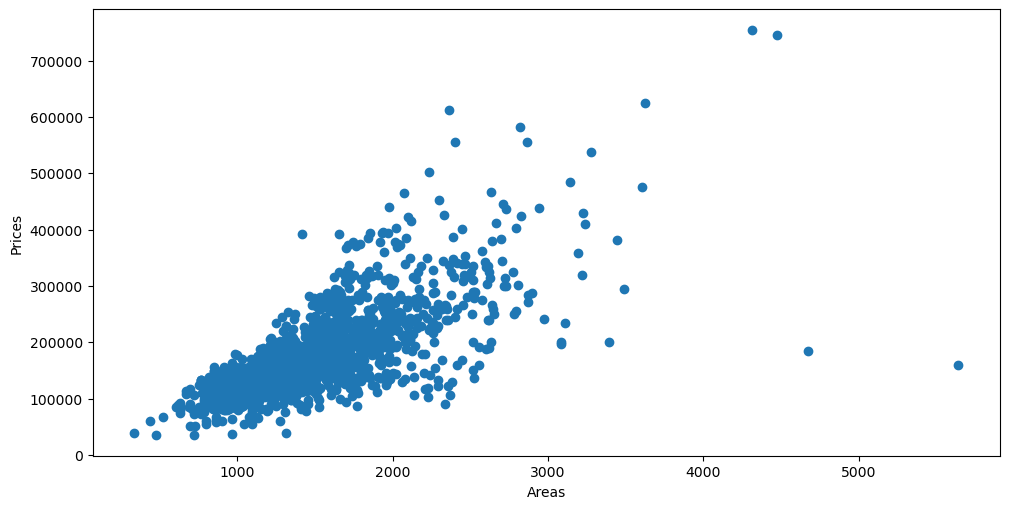

In [10]:
""" Чистка данных """

fig, ax = plt.subplots(figsize=(10, 5))
var = 'GrLivArea'
ax.scatter(raw_train_data[var], raw_train_data[target])
plt.tight_layout()
ax.set_ylabel('Prices')
ax.set_xlabel('Areas')
plt.show()

In [11]:
df = raw_train_data.copy()
df = df[(df[var] >= 4000) & (df[target] < 300_000)].index
# print(df[[var, target]])
# df[[var, target]].index
print(raw_train_data.shape)

nd = raw_train_data.drop(df)
# print(nd.iloc[df])
print(nd.shape)

# raw_train_data.iloc[523]
    # if raw_train_data[var] >= 4_000 and raw_train_data[target] <= 300_000:
    #     raw_train_data[i]

(1460, 81)
(1458, 81)


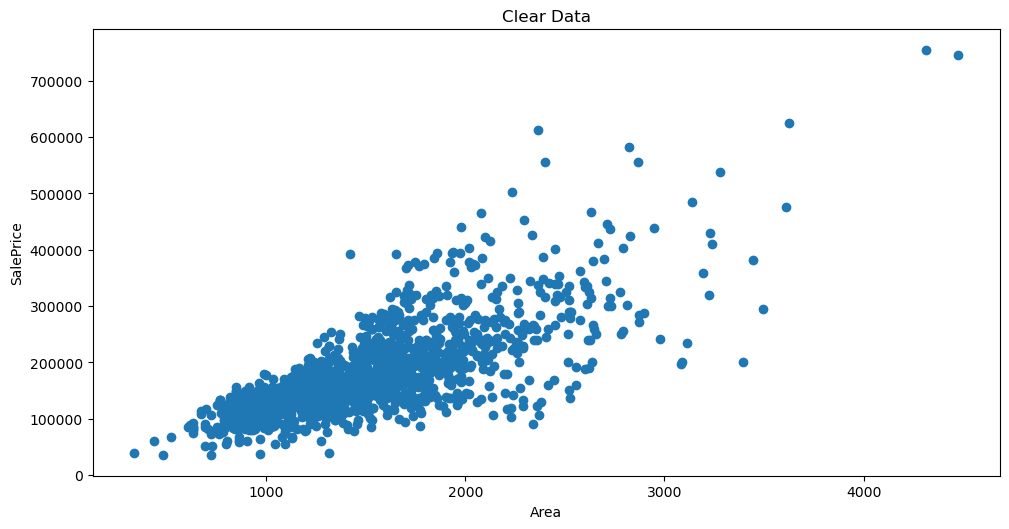

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(nd[var], nd[target])
plt.tight_layout()
ax.set_title('Clear Data')
ax.set_ylabel('SalePrice')
ax.set_xlabel('Area')
plt.show()

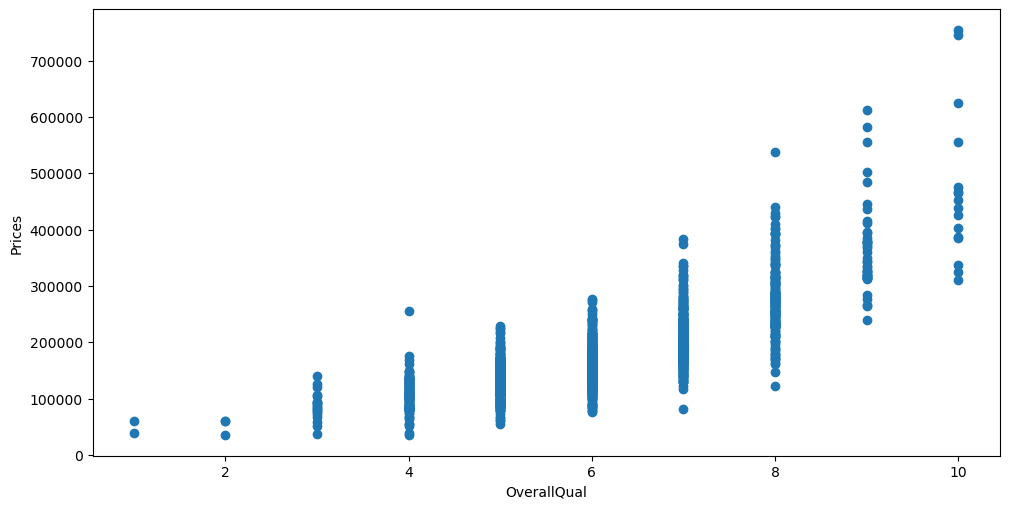

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
var = 'OverallQual'
ax.scatter(nd[var], nd[target])
plt.tight_layout()
ax.set_ylabel('Prices')
ax.set_xlabel('OverallQual')
plt.show()

In [14]:
a = (1, 2, 3)
hash(a)
# b = {'a': 2345, 'b': a}



529344067295497451

In [ ]:
df

Index([523, 1298], dtype='int64')

In [20]:
cat_none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType',
]
for col in cat_none_cols:
    raw_train_data[col] = raw_train_data[col].fillna('None')

num_zero_cols = ['GarageYrBlt', 'MasVnrArea']
for col in num_zero_cols:
    raw_train_data[col] = raw_train_data[col].fillna(0)

raw_train_data['LotFrontage'] = raw_train_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

raw_train_data['Electrical'] = raw_train_data['Electrical'].fillna(
    raw_train_data['Electrical'].mode()[0]
)

print(raw_train_data.isnull().sum().sum())  # должно быть 0

0


In [26]:
for col in raw_train_data.select_dtypes(include='number').columns:
    if raw_train_data[col].nunique() < 30:
        print(f'{col}: {raw_train_data[col].nunique()} unique - {sorted(raw_train_data[col].unique())}')

MSSubClass: 15 unique - [20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 160, 180, 190]
OverallQual: 10 unique - [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
OverallCond: 9 unique - [1, 2, 3, 4, 5, 6, 7, 8, 9]
LowQualFinSF: 24 unique - [0, 53, 80, 120, 144, 156, 205, 232, 234, 360, 371, 384, 390, 392, 397, 420, 473, 479, 481, 513, 514, 515, 528, 572]
BsmtFullBath: 4 unique - [0, 1, 2, 3]
BsmtHalfBath: 3 unique - [0, 1, 2]
FullBath: 4 unique - [0, 1, 2, 3]
HalfBath: 3 unique - [0, 1, 2]
BedroomAbvGr: 8 unique - [0, 1, 2, 3, 4, 5, 6, 8]
KitchenAbvGr: 4 unique - [0, 1, 2, 3]
TotRmsAbvGrd: 12 unique - [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14]
Fireplaces: 4 unique - [0, 1, 2, 3]
GarageCars: 5 unique - [0, 1, 2, 3, 4]
3SsnPorch: 20 unique - [0, 23, 96, 130, 140, 144, 153, 162, 168, 180, 182, 196, 216, 238, 245, 290, 304, 320, 407, 508]
PoolArea: 8 unique - [0, 480, 512, 519, 555, 576, 648, 738]
MiscVal: 21 unique - [0, 54, 350, 400, 450, 480, 500, 560, 600, 620, 700, 800, 1150, 1200, 1300, 1400, 2000, 25

In [29]:
skewed = raw_train_data.select_dtypes(include='number').skew()
skew_col = skewed[skewed.abs() > 1].sort_values(ascending=False)
print(skew_col)

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677616
OpenPorchSF       2.364342
LotFrontage       2.212959
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
GarageYrBlt      -3.869501
dtype: float64


In [46]:
to_category = ['MSSubClass', 'YrSold', 'MoSold']
for cat in to_category:
    raw_train_data[cat] = raw_train_data[cat].astype(str)

skewed_cols = skewed[skewed.abs() > 1].index.tolist()
skewed_cols = [c for c in skewed_cols if c != 'SalePrice'
               and raw_train_data[c].dtype != 'object']

for col in skewed_cols:
    if (raw_train_data[col] >= 0).all():
        raw_train_data[col] = np.log1p(raw_train_data[col])

print(raw_train_data[skewed_cols].skew())

LotFrontage      -1.643798
LotArea          -0.873116
MasVnrArea        0.391045
BsmtFinSF1       -0.770297
BsmtFinSF2        2.426694
TotalBsmtSF      -6.039850
1stFlrSF         -0.135789
LowQualFinSF      7.301183
GrLivArea        -0.241078
BsmtHalfBath      3.862875
KitchenAbvGr     -9.257890
GarageYrBlt      -3.887733
WoodDeckSF        0.085915
OpenPorchSF      -0.201568
EnclosedPorch     2.048773
3SsnPorch         7.615543
ScreenPorch       3.113640
PoolArea         14.352750
MiscVal           5.017454
dtype: float64
